# Mohr-Coulomb Validation — Embedded Crack with NCP Contact

Biaxial compression on a unit square with an embedded (non-boundary-intersecting) crack.
The background stress state is carried entirely by **s0/w0 offsets** — the solver computes
only the perturbation.  Two test cases validate the NCP formulation against the classical
Mohr-Coulomb criterion:

1. **Locked** (θ < θ_crit): perturbation is zero, crack stays closed.
2. **Sliding** (θ > θ_crit): NCP releases, crack slides.

## 1. Imports

In [1]:
import os
os.environ.setdefault('OMP_NUM_THREADS', '4')

import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

from skfem.models.elasticity import lame_parameters

from poroelasticity import CGPoroelastostatics, CrackMeshBuilder
from poroelasticity.cg_dashboard import CGPoroelasticDashboard

import solve_nivp
from solve_nivp.ncp_contact import build_dynamic_ncp_contact

print(f"solve_nivp version: {getattr(solve_nivp, '__version__', 'dev')}")
print('Imports OK')

solve_nivp version: dev
Imports OK


## 2. Configuration

`ALPHA_BIOT = 0` decouples fluid and solid — pure elastodynamics.  High bulk viscous
damping (`BULK_MU_V`, `BULK_LAM_V`) overdamps the system so the Radau IIA time-stepping
is effectively quasi-static.  The crack is embedded at `(0.5, 0.5)` with length 0.4,
well inside the unit square.

In [2]:
# --- Material (Biot off, overdamped) ---
NU          = 0.25
G_SHEAR     = 22.0e3               # MPa
E_YOUNG     = 2.0 * G_SHEAR * (1.0 + NU)
ALPHA_BIOT  = 0.0
BETA_FLUID  = 8.5e-5
ETA_FLUID   = 2.0e-18 / 3600.0
K_PERM      = 1.0e-15 * 1.0e-6
DENSITY     = 1.0
BULK_MU_V   = 1.0e6                # large shear viscosity → overdamped
BULK_LAM_V  = 1.0e6                # large bulk viscosity → overdamped
SCALE_L     = 1.0
SCALE_EPS   = 1.0e-3

# --- Domain ---
XMIN, XMAX = 0.0, 1.0
YMIN, YMAX = 0.0, 1.0
N_ELEM     = 20

# --- Crack geometry ---
CRACK_X0     = 0.5
CRACK_Y0     = 0.5
CRACK_LENGTH = 0.4

# --- Loading (compression positive, MPa) ---
SIGMA_RIGHT = 10.0
SIGMA_TOP   = 30.0

# --- Friction ---
MU = 0.6

# --- Time stepping ---
TMAX    = 5.0
H_FIXED = 0.5

# --- Derived ---
LAM, MU_LAME = lame_parameters(E_YOUNG, NU)
PARAMS = (MU_LAME, LAM, ALPHA_BIOT, BETA_FLUID, K_PERM / ETA_FLUID)

# Principal stresses (compression positive)
S1 = max(SIGMA_RIGHT, SIGMA_TOP)   # σ₁ = 30 (vertical)
S3 = min(SIGMA_RIGHT, SIGMA_TOP)   # σ₃ = 10 (horizontal)

print(f"Domain:  [{XMIN},{XMAX}] × [{YMIN},{YMAX}],  N_ELEM = {N_ELEM}")
print(f"Crack:   centre=({CRACK_X0},{CRACK_Y0}), length={CRACK_LENGTH}")
print(f"Loading: σ_right={SIGMA_RIGHT}, σ_top={SIGMA_TOP}  →  σ₁={S1}, σ₃={S3}")
print(f"Friction: μ = {MU}")
print(f"Damping: bulk_mu_v={BULK_MU_V:.1e}, bulk_lam_v={BULK_LAM_V:.1e}")
print(f"Time:    tmax={TMAX}, h={H_FIXED}")

Domain:  [0.0,1.0] × [0.0,1.0],  N_ELEM = 20
Crack:   centre=(0.5,0.5), length=0.4
Loading: σ_right=10.0, σ_top=30.0  →  σ₁=30.0, σ₃=10.0
Friction: μ = 0.6
Damping: bulk_mu_v=1.0e+06, bulk_lam_v=1.0e+06
Time:    tmax=5.0, h=0.5


## 3. Analytical Mohr-Coulomb

On a plane at angle θ from σ₁ (compression positive):

$$\sigma_N(\theta) = \frac{\sigma_1 + \sigma_3}{2} + \frac{\sigma_1 - \sigma_3}{2}\cos 2\theta, \qquad
\tau(\theta) = \frac{\sigma_1 - \sigma_3}{2}\sin 2\theta$$

Coulomb failure (cohesionless): $|\tau| = \mu\,\sigma_N$.
Critical angle: $\theta_{\mathrm{crit}} = \tfrac{1}{2}\arctan(1/\mu)$.

**Angle convention:** `CrackMeshBuilder` parameterizes `crack_theta` as the angle of the
crack *line* measured counter-clockwise from the y-axis.  With σ₁ vertical, a Mohr angle
θ from σ₁ corresponds to `crack_theta = π/2 − θ`.

In [3]:
# Critical angle
phi = np.arctan(MU)
theta_crit = 0.5 * np.arctan(1.0 / MU)

# Test angles (Mohr angle from σ₁)
THETA_LOCKED  = np.radians(20.0)    # well inside the cone
THETA_SLIDING = np.radians(35.0)    # outside the cone

# Mohr tractions as a function of angle
def mohr_tractions(theta):
    sigma_N = (S1 + S3) / 2 + (S1 - S3) / 2 * np.cos(2 * theta)
    tau     = (S1 - S3) / 2 * np.sin(2 * theta)
    return sigma_N, tau

# Tractions at test angles
sN_locked,  tau_locked  = mohr_tractions(THETA_LOCKED)
sN_sliding, tau_sliding = mohr_tractions(THETA_SLIDING)

# Angle convention: crack_theta for CrackMeshBuilder
CRACK_THETA_LOCKED  = np.pi / 2 - THETA_LOCKED
CRACK_THETA_SLIDING = np.pi / 2 - THETA_SLIDING

print(f"θ_crit = {np.degrees(theta_crit):.2f}° from σ₁")
print(f"φ = arctan(μ) = {np.degrees(phi):.2f}°")
print()
print(f"Locked test  (θ = {np.degrees(THETA_LOCKED):.0f}°):")
print(f"  σ_N = {sN_locked:.2f},  τ = {tau_locked:.2f},  μσ_N = {MU*sN_locked:.2f}")
print(f"  |τ|/μσ_N = {abs(tau_locked)/(MU*sN_locked):.4f}  (< 1 → locked)")
print(f"  crack_theta = {np.degrees(CRACK_THETA_LOCKED):.1f}°")
print()
print(f"Sliding test (θ = {np.degrees(THETA_SLIDING):.0f}°):")
print(f"  σ_N = {sN_sliding:.2f},  τ = {tau_sliding:.2f},  μσ_N = {MU*sN_sliding:.2f}")
print(f"  |τ|/μσ_N = {abs(tau_sliding)/(MU*sN_sliding):.4f}  (> 1 → sliding)")
print(f"  crack_theta = {np.degrees(CRACK_THETA_SLIDING):.1f}°")

θ_crit = 29.52° from σ₁
φ = arctan(μ) = 30.96°

Locked test  (θ = 20°):
  σ_N = 27.66,  τ = 6.43,  μσ_N = 16.60
  |τ|/μσ_N = 0.3873  (< 1 → locked)
  crack_theta = 70.0°

Sliding test (θ = 35°):
  σ_N = 23.42,  τ = 9.40,  μσ_N = 14.05
  |τ|/μσ_N = 0.6687  (> 1 → sliding)
  crack_theta = 55.0°


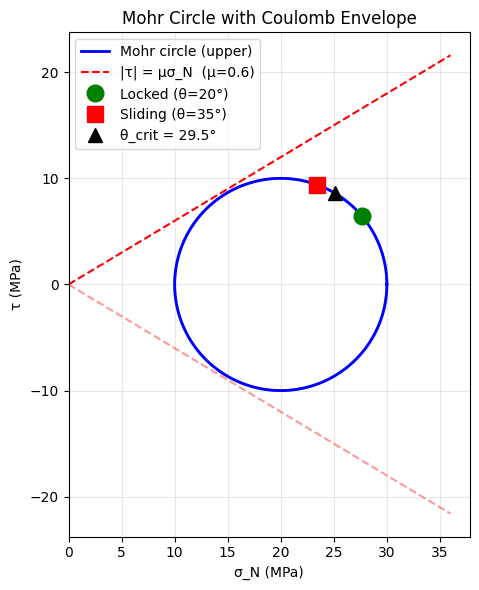

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

# Mohr circle
theta_range = np.linspace(0, np.pi, 300)
sN_range, tau_range = mohr_tractions(theta_range)
ax.plot(sN_range, tau_range, 'b-', lw=2, label='Mohr circle (upper)')
ax.plot(sN_range, -tau_range, 'b-', lw=2, alpha=0.4)

# Coulomb envelope
sN_env = np.linspace(0, S1 * 1.2, 100)
ax.plot(sN_env, MU * sN_env, 'r--', lw=1.5, label=f'|τ| = μσ_N  (μ={MU})')
ax.plot(sN_env, -MU * sN_env, 'r--', lw=1.5, alpha=0.4)

# Test points
ax.plot(sN_locked, tau_locked, 'go', ms=12, zorder=5,
        label=f'Locked (θ={np.degrees(THETA_LOCKED):.0f}°)')
ax.plot(sN_sliding, tau_sliding, 'rs', ms=12, zorder=5,
        label=f'Sliding (θ={np.degrees(THETA_SLIDING):.0f}°)')

# Critical point
sN_crit, tau_crit = mohr_tractions(theta_crit)
ax.plot(sN_crit, tau_crit, 'k^', ms=10, zorder=5,
        label=f'θ_crit = {np.degrees(theta_crit):.1f}°')

ax.set_xlabel('σ_N (MPa)')
ax.set_ylabel('τ (MPa)')
ax.set_title('Mohr Circle with Coulomb Envelope')
ax.legend(loc='upper left')
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()